In [14]:
#learning underfitting and overfitting
import seaborn as sns
titanic=sns.load_dataset("titanic")


In [15]:
import pandas as pd
titanic = pd.read_csv("titanic.csv")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [16]:
titanic[['pclass','sex','age','fare','survived']].isnull().sum()

pclass        0
sex           0
age         177
fare          0
survived      0
dtype: int64

In [17]:
data = titanic[['pclass','sex','age','fare','survived']].copy()

data['age'] = data['age'].fillna(data['age'].mean())
print(data.isnull().sum())

pclass      0
sex         0
age         0
fare        0
survived    0
dtype: int64


In [18]:
data['sex']=data['sex'].map({
    'male':0,
    'female':1
})
print(data.head())
print(data.dtypes)

   pclass  sex   age     fare  survived
0       3    0  22.0   7.2500         0
1       1    1  38.0  71.2833         1
2       3    1  26.0   7.9250         1
3       1    1  35.0  53.1000         1
4       3    0  35.0   8.0500         0
pclass        int64
sex           int64
age         float64
fare        float64
survived      int64
dtype: object


In [19]:
x=data[['pclass','sex','age','fare']]#features of the model
y=data['survived']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
#scaling the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)#training data
x_test_scale=scaler.transform(x_test)#test data

In [21]:
#logistic model training
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(x_train_scale,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
y_pred=model.predict(x_test_scale)
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [23]:
from sklearn.metrics import accuracy_score
accu=accuracy_score(y_test,y_pred)
print("accuracy",accu)

accuracy 0.7988826815642458


In [24]:
#confusion matrix calculated from the data
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[90 15]
 [21 53]]


In [25]:
#recall score and f1_score
from sklearn.metrics import recall_score,precision_score,f1_score
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))

precision 0.7794117647058824
recall 0.7162162162162162
f1_score 0.7464788732394366


AUC Score: 0.8733590733590735


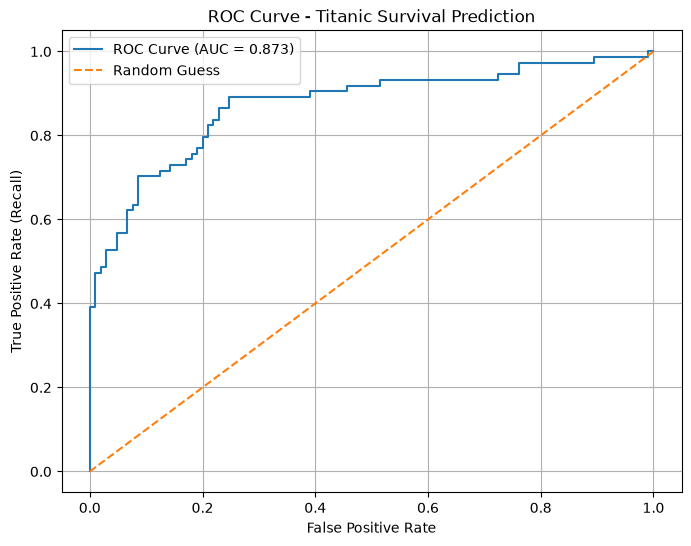

In [27]:
#auc and roc score check
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of survival
y_prob = model.predict_proba(x_test_scale)[:,1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")

# Random Guess Line
plt.plot([0,1], [0,1], linestyle='--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Titanic Survival Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
for i in range(10):
    print(
        f"Prob={y_prob[i]:.3f}  "
        f"Actual={y_test.iloc[i]}  "
        f"Pred={y_pred[i]}"
    )

Prob=0.095  Actual=1  Pred=0
Prob=0.218  Actual=0  Pred=0
Prob=0.118  Actual=0  Pred=0
Prob=0.873  Actual=1  Pred=1
Prob=0.666  Actual=1  Pred=1
Prob=0.923  Actual=1  Pred=1
Prob=0.571  Actual=1  Pred=1
Prob=0.130  Actual=0  Pred=0
Prob=0.653  Actual=1  Pred=1
Prob=0.931  Actual=1  Pred=1
